### Import seeds from DisGeNET query file

In [18]:
import pandas as pd

In [19]:
disgenet_res = pd.read_csv('disease_seeds/cystic_fibrosis_disgenet.tsv', sep='\t')


In [20]:
disgenet_res.head()

,ei,N CTs,N variants g,N PMIDs Chemicals,Gene,pLI,Gene Full Name,First Ref.,Last Ref.,N Chemicals,N PMIDs,score,N diseases g,My Score,DSI g,DPI g,N variants gda
0,0.971220,93,2607,0,CFTR,2.164600e-39,CF transmembrane conductance regulator,1969.0,2025.0,0,1764,1.00,56,NaN,0.40,0.88,2489
1,1.000000,7,49,0,TGFB1,2.596500e-02,transforming growth factor beta 1,1993.0,2020.0,0,21,1.00,142,NaN,0.28,0.92,4
2,0.936508,5,170,0,SERPINA1,8.189900e-07,serpin family A member 1,1993.0,2020.0,0,22,0.95,46,NaN,0.38,0.88,1
3,0.812500,43,9,0,TNF,8.568700e-01,tumor necrosis factor,NaN,NaN,0,0,0.90,315,NaN,0.25,0.96,0
4,0.852941,24,5,0,IL1B,4.876100e-01,interleukin 1 beta,NaN,NaN,0,0,0.90,166,NaN,0.28,0.96,0


In [21]:
input_genes = list(disgenet_res['Gene'])
input_genes[:10]

['CFTR',
 'TGFB1',
 'SERPINA1',
 'TNF',
 'IL1B',
 'MPO',
 'SCNN1A',
 'MBL2',
 'HFE',
 'SCNN1B']

In [22]:
if len(input_genes) > 150:
    input_genes = input_genes[:150]

len(input_genes)

66

### Import hidef output

##### Import HiDeF persistent cluster assignments

In [23]:

# Import nodes file from HiDeF output (test_run_1_.nodes) into a dictionary with cluster id as key and list of genes as value
nodes_df = pd.read_csv('output_examples/test_run_k10_.nodes', sep='\t', header=None)

# Column 0: cluster name, column 1: size, column 2: space-separated genes
nodes_dict = {
    row[0]: row[2].split()
    for _, row in nodes_df.iterrows()
}


#### Import HiDeF Hierarchy Graph

In [24]:
hierarchy_graph = pd.read_csv('output_examples/test_run_k10_.edges', sep='\t', header=None)
hierarchy_graph.head()

,0,1,2
0,Cluster0-0,Cluster1-0,default
1,Cluster0-0,Cluster1-1,default
2,Cluster0-0,Cluster1-2,default
3,Cluster0-0,Cluster1-3,default
4,Cluster0-0,Cluster1-4,default


In [25]:
hierarchy_graph.shape

(1204, 3)

### Identify Persistent clusters with disease genes

In [26]:
# get all clusters that contain at least one of the input genes
clusters_with_input_genes = {
    cluster_id: genes
    for cluster_id, genes in nodes_dict.items()
    if any(gene in input_genes for gene in genes)
}

clusters_with_input_genes.keys()

dict_keys(['Cluster0-0', 'Cluster1-0', 'Cluster1-1', 'Cluster2-0', 'Cluster2-2', 'Cluster2-1', 'Cluster1-2', 'Cluster3-0', 'Cluster2-3', 'Cluster3-1', 'Cluster3-3', 'Cluster4-0', 'Cluster2-5', 'Cluster3-5', 'Cluster2-7', 'Cluster2-8', 'Cluster3-6', 'Cluster4-2', 'Cluster2-19', 'Cluster3-13', 'Cluster4-4', 'Cluster2-47', 'Cluster2-52', 'Cluster2-68', 'Cluster2-90', 'Cluster3-64', 'Cluster3-72', 'Cluster1-51', 'Cluster4-32', 'Cluster2-275', 'Cluster2-334', 'Cluster3-182', 'Cluster2-408', 'Cluster2-511', 'Cluster2-552'])

In [27]:
# Get the subgraph of the hierarchy graph that only contains clusters with input genes
reduced_hierarchy_graph = hierarchy_graph[
    (hierarchy_graph[0].isin(clusters_with_input_genes.keys())) &
    (hierarchy_graph[1].isin(clusters_with_input_genes.keys()))
]

In [28]:
reduced_hierarchy_graph.head()

,0,1,2
0,Cluster0-0,Cluster1-0,default
1,Cluster0-0,Cluster1-1,default
2,Cluster0-0,Cluster1-2,default
51,Cluster0-0,Cluster1-51,default
214,Cluster1-0,Cluster2-2,default


In [29]:
reduced_hierarchy_graph.shape

(34, 3)

#### Fisher Test (Genes in HiDeF clusters)

In [30]:
from scipy.stats import hypergeom
from statsmodels.stats.multitest import multipletests

# Background: all unique genes across all clusters
all_genes = set(gene for genes in nodes_dict.values() for gene in genes)
N = len(all_genes)  # total background genes

# Disease genes present in the background
disease_genes_in_background = set(input_genes) & all_genes
K = len(disease_genes_in_background)  # total disease genes in background

results = []
for cluster_id, genes in clusters_with_input_genes.items():
    n = len(genes)  # cluster size
    k = sum(1 for gene in genes if gene in disease_genes_in_background)  # disease genes in cluster
    
    # Hypergeometric test: P(X >= k) = 1 - P(X <= k-1)
    p_value = hypergeom.sf(k - 1, N, K, n)
    
    results.append({
        'cluster': cluster_id,
        'cluster_size': n,
        'disease_genes_in_cluster': k,
        'total_background': N,
        'total_disease_genes': K,
        'p_value': p_value
    })

results_df = pd.DataFrame(results).sort_values('p_value')

# Multiple testing correction (Benjamini-Hochberg FDR)
_, results_df['p_adj'], _, _ = multipletests(results_df['p_value'], method='fdr_bh')

# Mark significant clusters
results_df['significant'] = results_df['p_adj'] < 0.05

print(f"Background: {N} genes, {K} disease genes")
print(f"\nTotal clusters tested: {len(results_df)}")
print(f"Significant clusters (FDR < 0.05): {results_df['significant'].sum()}")
print()

# Filter significant entries with only 1 disease gene 
results_df = results_df[results_df['disease_genes_in_cluster'] > 1]

results_df.head(20)


Background: 17053 genes, 51 disease genes

Total clusters tested: 35
Significant clusters (FDR < 0.05): 5



,cluster,cluster_size,disease_genes_in_cluster,total_background,total_disease_genes,p_value,p_adj,significant
31,Cluster3-182,5,3,17053,51,2.509426e-07,0.000009,True
29,Cluster2-275,7,3,17053,51,8.745951e-07,0.000015,True
30,Cluster2-334,6,2,17053,51,1.305344e-04,0.001523,True
13,Cluster3-5,137,4,17053,51,7.434878e-04,0.006506,True
21,Cluster2-47,36,2,17053,51,5.177031e-03,0.036239,True
8,Cluster2-3,456,5,17053,51,1.144352e-02,0.052107,False
17,Cluster4-2,72,2,17053,51,1.961678e-02,0.068659,False
6,Cluster1-2,688,5,17053,51,5.390505e-02,0.114397,False
5,Cluster2-1,694,5,17053,51,5.556433e-02,0.114397,False
14,Cluster2-7,132,2,17053,51,5.928195e-02,0.115270,False


##### Plot Hierarchy (with significant Fisher test nodes)

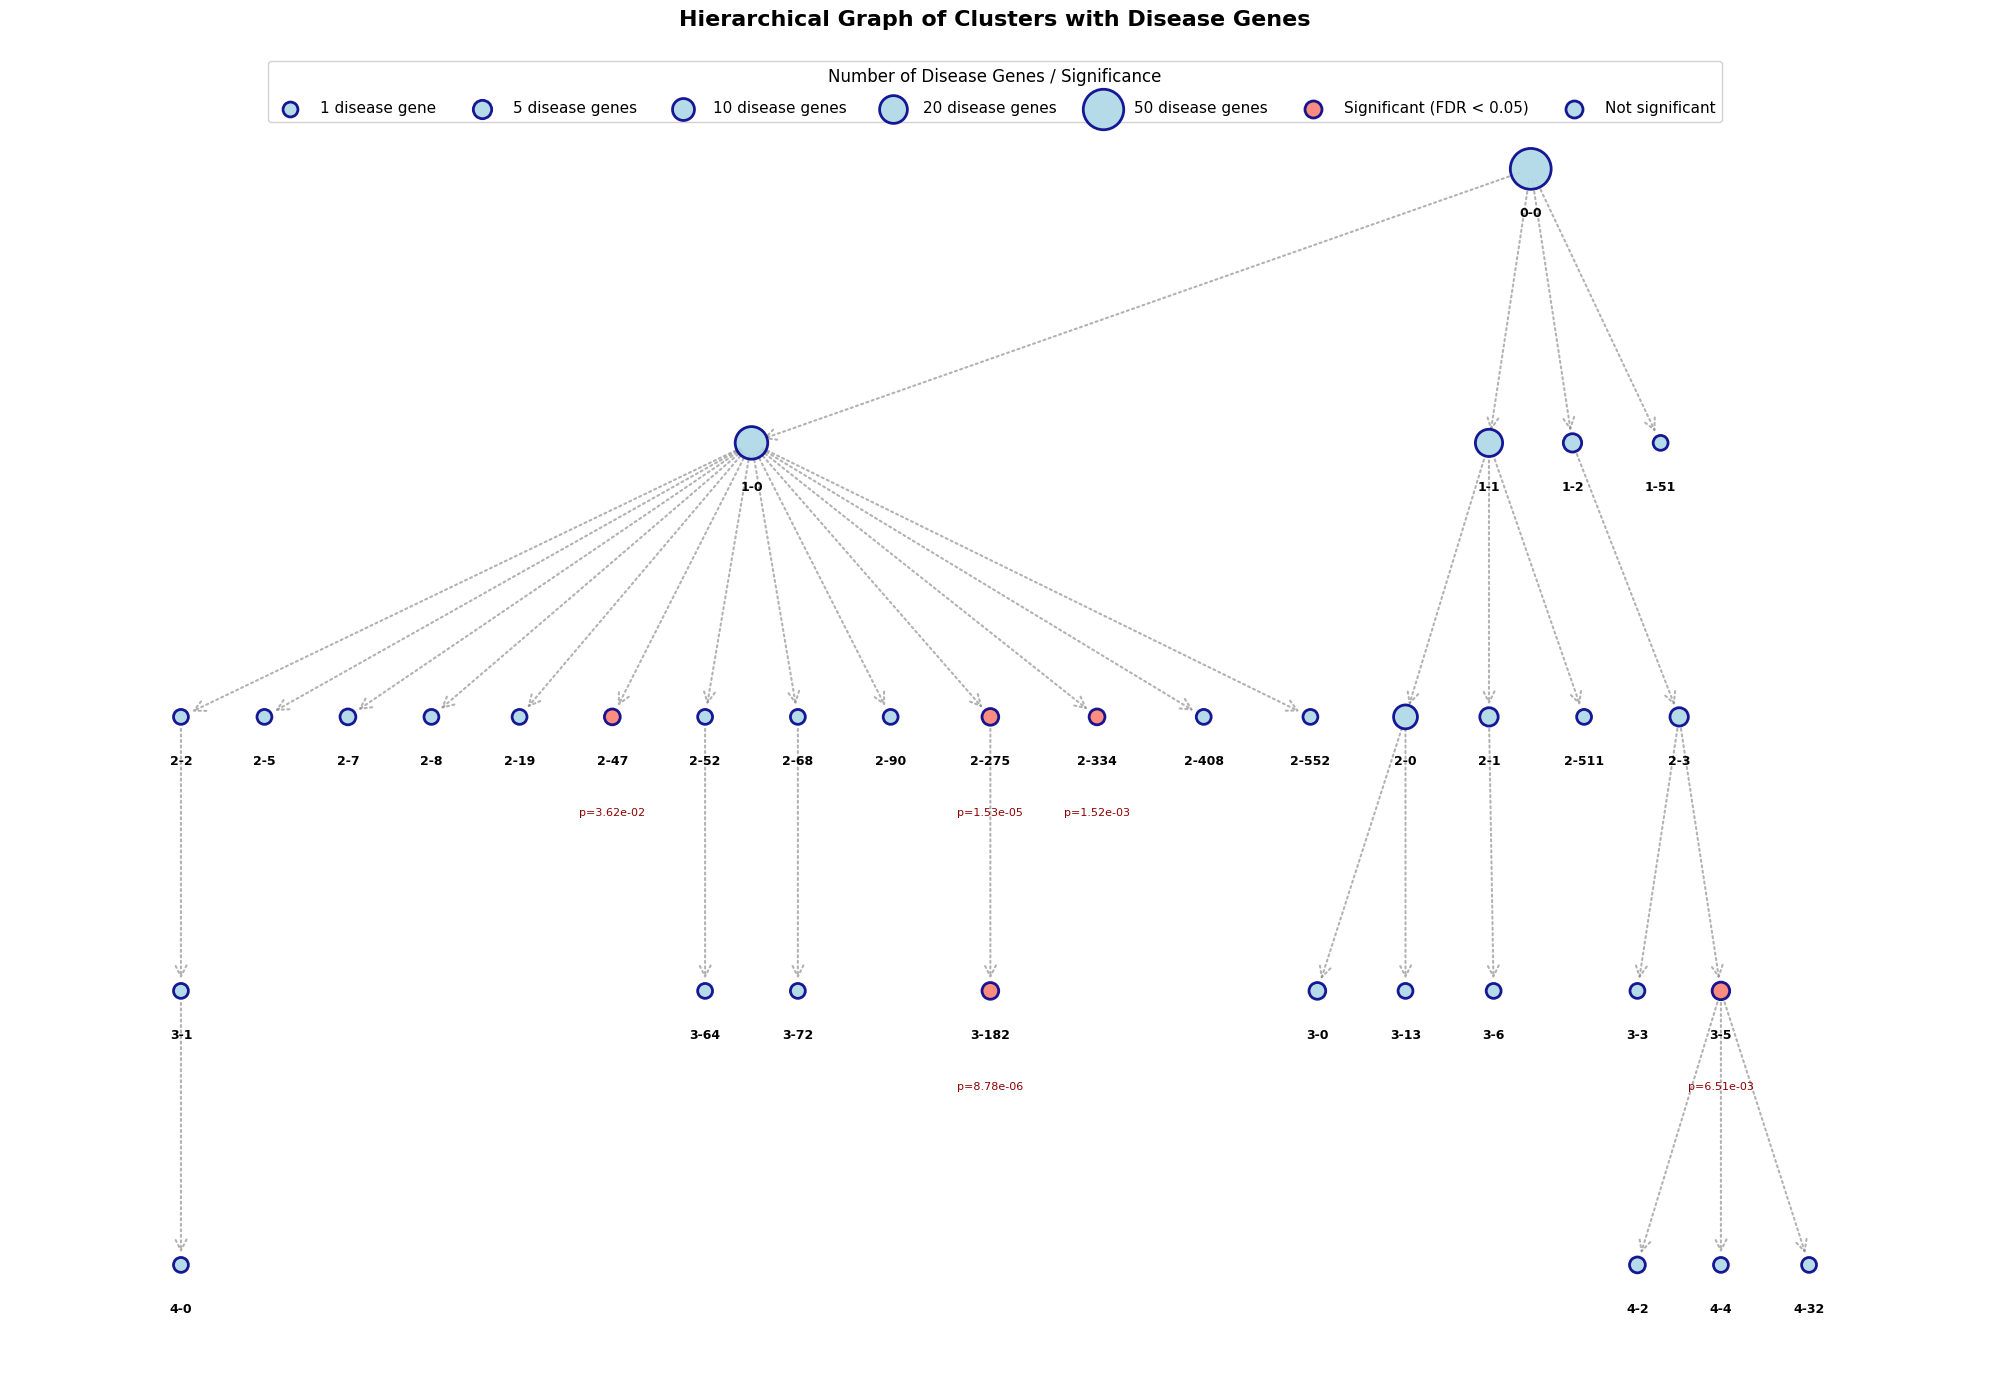

In [31]:
import networkx as nx
import matplotlib.pyplot as plt
import pygraphviz


# Create a directed graph from the reduced hierarchy graph
G = nx.from_pandas_edgelist(reduced_hierarchy_graph, source=0, target=1, create_using=nx.DiGraph())

# Build a lookup from cluster_id -> significance and p_adj
sig_lookup = results_df.set_index('cluster')[['significant', 'p_adj']].to_dict('index')

# Calculate node sizes based on number of disease genes in each cluster
node_sizes = {}
for node in G.nodes():
    if node in clusters_with_input_genes:
        disease_gene_count = sum(1 for gene in clusters_with_input_genes[node] if gene in input_genes)
        node_sizes[node] = 100 + (disease_gene_count * 15)
    else:
        node_sizes[node] = 100

# Create node size list in the order of nodes
sizes = [node_sizes[node] for node in G.nodes()]

# Assign colors
node_colors = []
for node in G.nodes():
    if node in sig_lookup and sig_lookup[node]['significant']:
        node_colors.append('salmon')
    else:
        node_colors.append('lightblue')

# Keep a mapping from new label -> old label to look up significance
old_to_new = {node: node.replace('Cluster', '') for node in G.nodes()}
sig_lookup_new = {old_to_new[k]: v for k, v in sig_lookup.items() if k in old_to_new}

G = nx.relabel_nodes(G, lambda x: x.replace('Cluster', ''))

# Use hierarchical layout with graphviz
pos = nx.nx_agraph.graphviz_layout(G, prog='dot')

# Offset label positions below each node
label_offset = 10
label_pos = {node: (x, y - label_offset) for node, (x, y) in pos.items()}

# Build p-value labels only for significant nodes
pval_labels = {}
for node in G.nodes():
    if node in sig_lookup_new and sig_lookup_new[node]['significant']:
        p = sig_lookup_new[node]['p_adj']
        pval_labels[node] = f"p={p:.2e}"

# Offset p-value label further below
pval_label_offset = 24
pval_pos = {node: (x, y - pval_label_offset) for node, (x, y) in pos.items()}

# Create figure with better size
plt.figure(figsize=(20, 14), facecolor='white')

# Draw the graph
nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=node_colors,
                       edgecolors='darkblue', linewidths=2, alpha=0.9)
nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True,
                       arrowsize=20, arrowstyle='->', width=1.5, alpha=0.6, style='dotted')
nx.draw_networkx_labels(G, label_pos, font_size=9, font_weight='bold', font_family='sans-serif', verticalalignment='top')

# Draw p-value labels for significant nodes
nx.draw_networkx_labels(G, pval_pos, labels=pval_labels, font_size=8,
                        font_color='darkred', verticalalignment='top')

# Add title
plt.title('Hierarchical Graph of Clusters with Disease Genes', 
          fontsize=16, fontweight='bold', pad=20)

# Create legend for node sizes
legend_sizes = [1, 5, 10, 20, 50]
legend_elements = [plt.scatter([], [], s=100 + (s * 15), c='lightblue',
                              edgecolors='darkblue', linewidths=2, alpha=0.9,
                              label=f'{s} disease gene{"s" if s > 1 else ""}')
                  for s in legend_sizes]

# Add color legend entries
legend_elements += [
    plt.scatter([], [], s=150, c='salmon', edgecolors='darkblue', linewidths=2, alpha=0.9, label='Significant (FDR < 0.05)'),
    plt.scatter([], [], s=150, c='lightblue', edgecolors='darkblue', linewidths=2, alpha=0.9, label='Not significant'),
]

plt.legend(handles=legend_elements, loc='upper center', fontsize=11,
          title='Number of Disease Genes / Significance', title_fontsize=12, framealpha=0.9,
          labelspacing=1, handletextpad=1, ncol=len(legend_elements))

plt.axis('off')
plt.tight_layout()
plt.show()


### GSEA

In [32]:
import gseapy as gp
from multiprocessing import Pool

# Gene set databases to query
gene_sets = ['KEGG_2021_Human', 'Reactome_Pathways_2024','WikiPathways_2024_Human','GO_Molecular_Function_2025']

# Get significant clusters
significant_clusters = results_df[results_df['significant']]['cluster'].tolist()

gsea_results = {}

def run_enrichr(cluster_id):
    """Run Enrichr for a single cluster and return results"""
    genes = clusters_with_input_genes[cluster_id]
    
    enr = gp.enrichr(
        gene_list=genes,
        gene_sets=gene_sets,
        organism='human',
        outdir=None,
        background=all_genes,
        verbose=False
    )
    
    n_sig = (enr.results['Adjusted P-value'] < 0.05).sum()
    print(f"{cluster_id} ({len(genes)} genes): {n_sig} significant terms (FDR < 0.05)")
    
    return (cluster_id, enr.results)

# Run enrichment analysis in parallel
with Pool() as pool:
    results_list = pool.map(run_enrichr, significant_clusters)

# Convert list of tuples back to dictionary
for cluster_id, results in results_list:
    gsea_results[cluster_id] = results


Cluster2-334 (6 genes): 31 significant terms (FDR < 0.05)
Cluster2-275 (7 genes): 34 significant terms (FDR < 0.05)Cluster2-47 (36 genes): 28 significant terms (FDR < 0.05)


Cluster2-275 (7 genes): 34 significant terms (FDR < 0.05)Cluster2-47 (36 genes): 28 significant terms (FDR < 0.05)

Cluster3-182 (5 genes): 20 significant terms (FDR < 0.05)
Cluster3-182 (5 genes): 20 significant terms (FDR < 0.05)
Cluster3-5 (137 genes): 129 significant terms (FDR < 0.05)
Cluster3-5 (137 genes): 129 significant terms (FDR < 0.05)


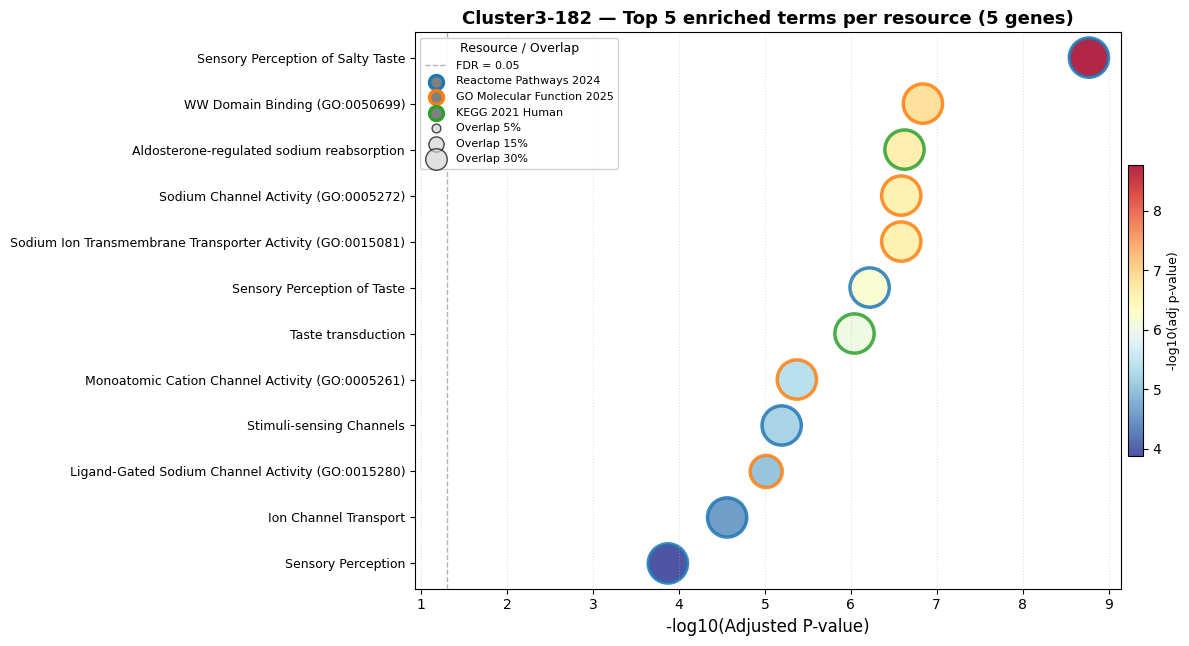

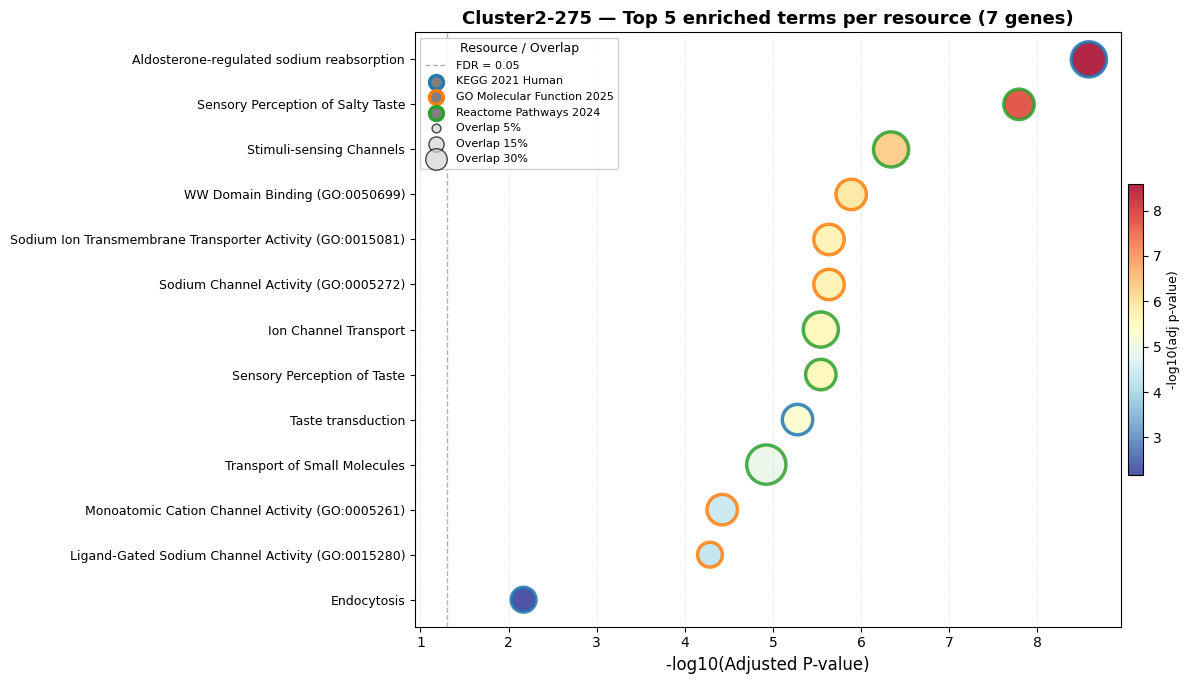

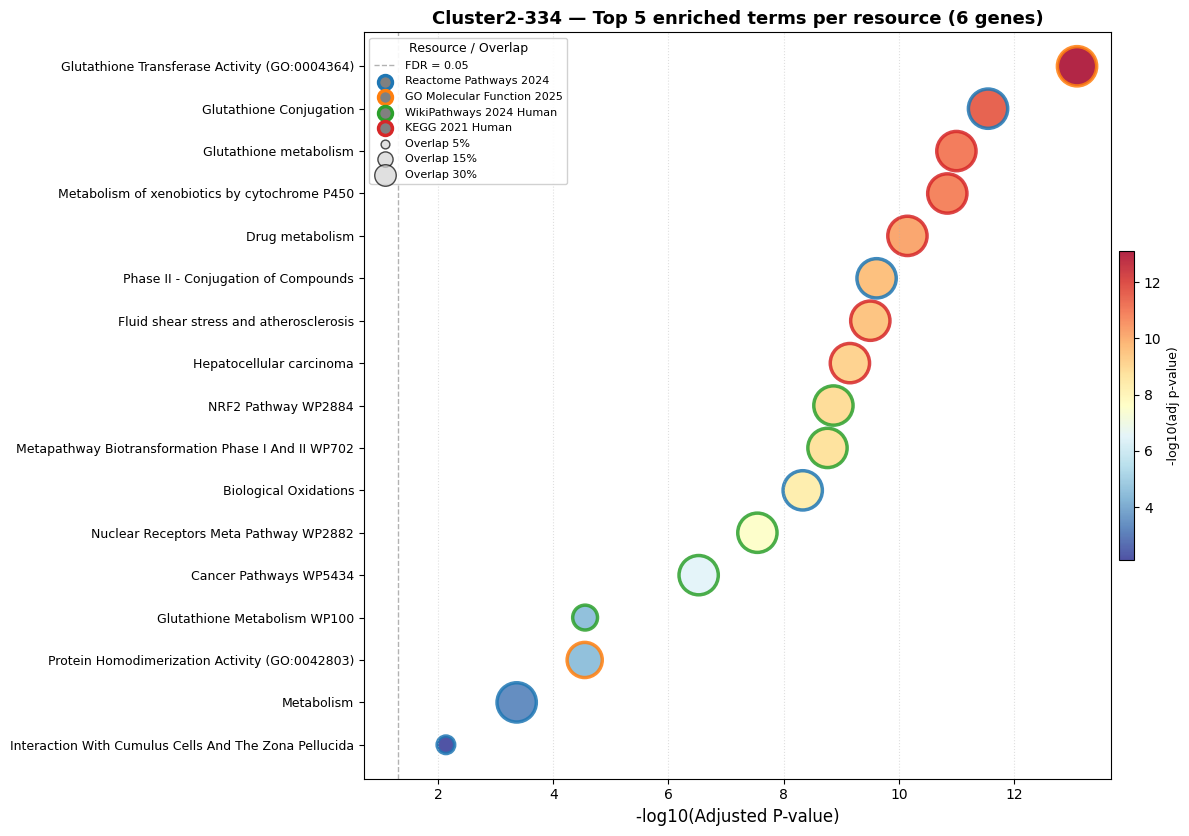

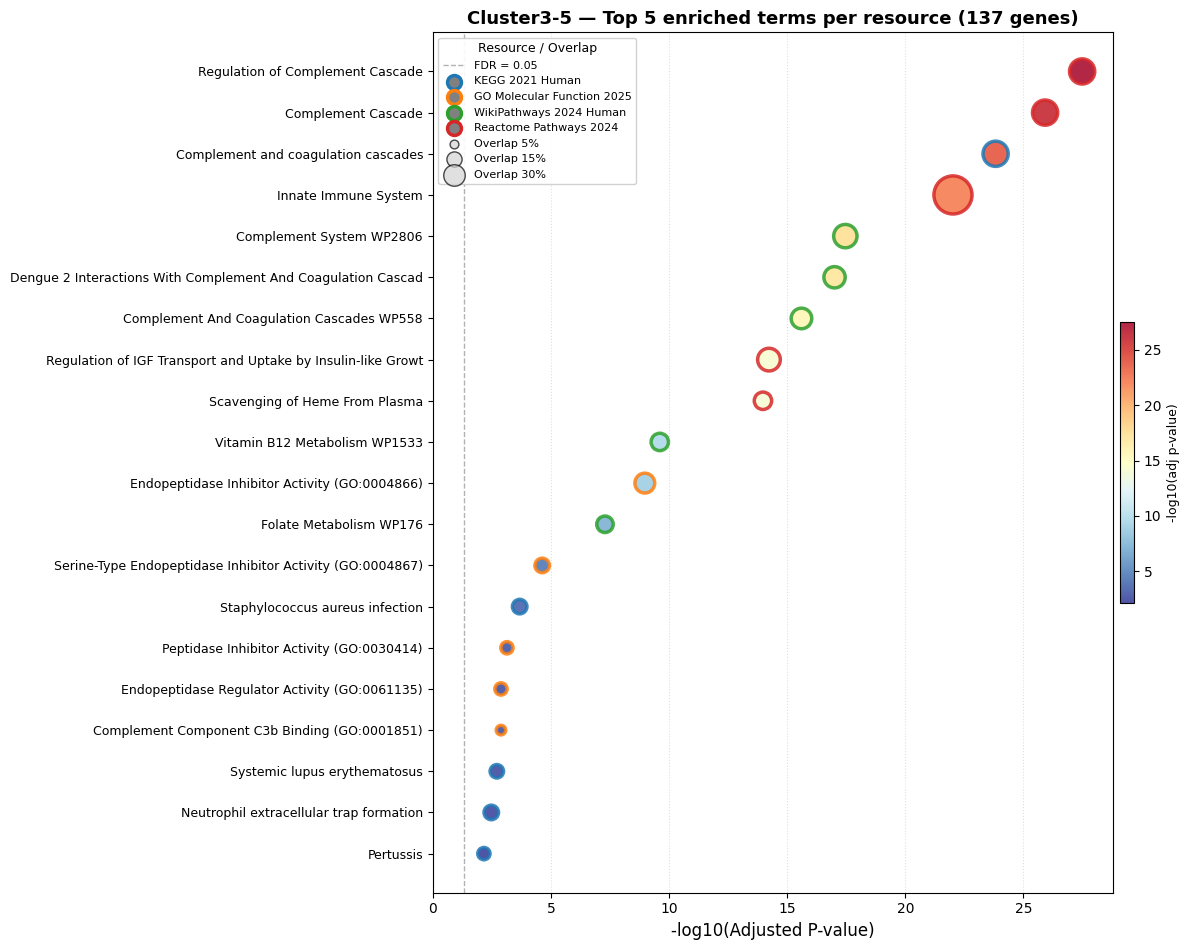

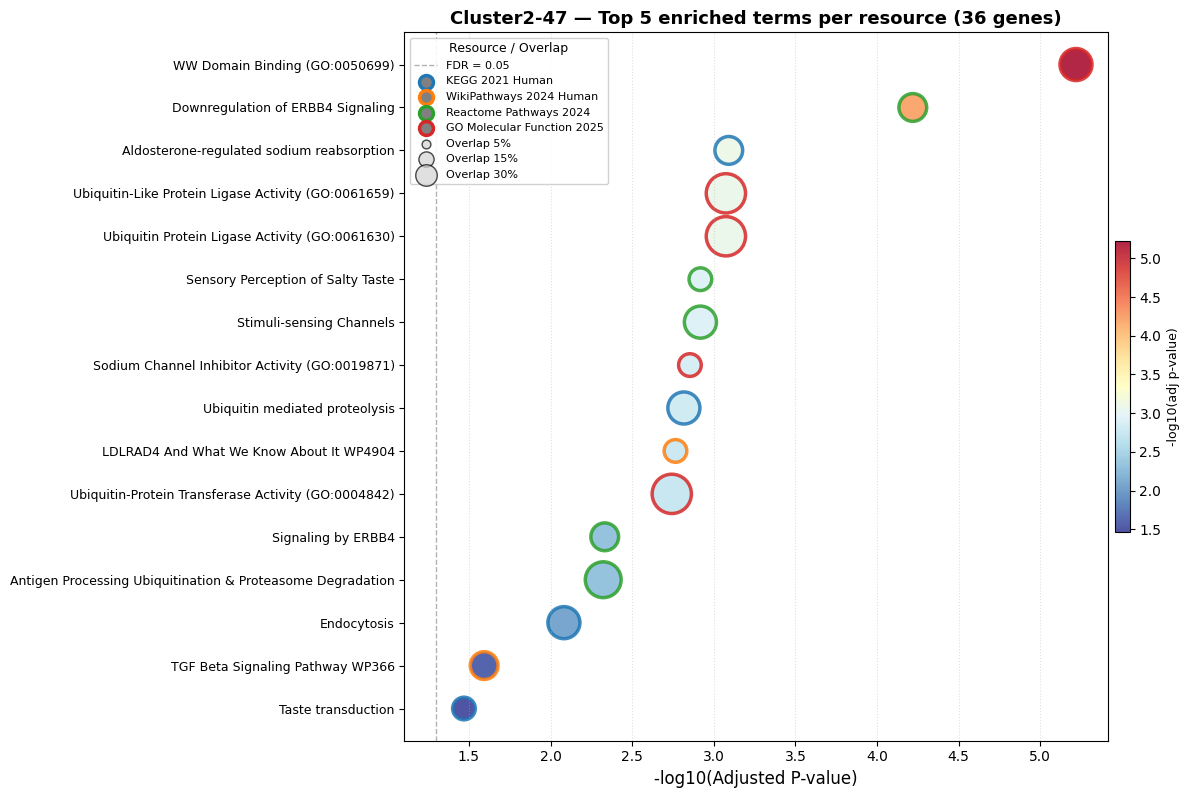

In [33]:
import numpy as np

# --- Parameters ---
top_n = 5        # top N terms per gene set resource per cluster
fdr_cutoff = 0.05

def parse_overlap(s):
    try:
        a, b = s.split('/')
        return int(a) / int(b)
    except:
        return 0.0

for cluster_id, df in gsea_results.items():
    df = df.copy()
    # Check for the overlap column name (could be 'Overlap' or 'Genes')
    if 'Overlap' in df.columns:
        df['overlap_ratio'] = df['Overlap'].apply(parse_overlap)
    elif 'Genes' in df.columns:
        # If there's no Overlap column, calculate from gene counts
        df['overlap_ratio'] = df['Genes'].str.split(';').apply(len) / df['Genes'].str.split(';').apply(len).max()
    else:
        df['overlap_ratio'] = 0.1  # default value
    df['-log10_padj'] = -np.log10(df['Adjusted P-value'].astype(float).clip(lower=1e-300))
    df['Term_short'] = df['Term'].str.slice(0, 60)

    # Select top N significant terms per gene set resource
    sig_df = df[df['Adjusted P-value'] < fdr_cutoff]
    top_df = (
        sig_df.sort_values('Adjusted P-value')
        .groupby('Gene_set')
        .head(top_n)
        .sort_values(['-log10_padj'], ascending=True)
    )

    if top_df.empty:
        print(f"{cluster_id}: no significant terms to plot.")
        continue

    # Color-code by gene set source
    sources = top_df['Gene_set'].unique()
    palette = plt.cm.tab10.colors
    source_colors = {src: palette[i % len(palette)] for i, src in enumerate(sources)}
    colors = [source_colors[s] for s in top_df['Gene_set']]

    fig, ax = plt.subplots(figsize=(12, max(5, len(top_df) * 0.38 + 2)), facecolor='white')

    scatter = ax.scatter(
        top_df['-log10_padj'],
        top_df['Term_short'],
        s=top_df['overlap_ratio'] * 800,
        c=top_df['-log10_padj'],
        cmap='RdYlBu_r',
        alpha=0.85,
        edgecolors=colors,
        linewidths=2.5
    )

    ax.axvline(x=-np.log10(fdr_cutoff), color='gray', linestyle='--', linewidth=1, alpha=0.6, label=f'FDR = {fdr_cutoff}')
    ax.set_xlabel('-log10(Adjusted P-value)', fontsize=12)
    ax.set_title(f'{cluster_id} — Top {top_n} enriched terms per resource ({len(clusters_with_input_genes[cluster_id])} genes)', fontsize=13, fontweight='bold')
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(axis='x', linestyle=':', alpha=0.4)

    # Colorbar for significance
    cbar = plt.colorbar(scatter, ax=ax, pad=0.01, fraction=0.02)
    cbar.set_label('-log10(adj p-value)', fontsize=9)

    # Gene set source legend (edge color)
    for src, col in source_colors.items():
        ax.scatter([], [], s=100, facecolors='gray', edgecolors=col, linewidths=2.5, label=src.replace('_', ' '))

    # Overlap size legend
    for ratio, label in [(0.05, '5%'), (0.15, '15%'), (0.30, '30%')]:
        ax.scatter([], [], s=ratio * 800, c='lightgray', edgecolors='black', linewidths=1, alpha=0.7, label=f'Overlap {label}')

    ax.legend(fontsize=8, loc='upper left', framealpha=0.9, title='Resource / Overlap', title_fontsize=9)

    plt.tight_layout()
    plt.show()


In [39]:
# obtain cluster where CFTR is present
for cluster_id, genes in nodes_dict.items():
    if 'CFTR' in genes:
        print(cluster_id)

Cluster0-0
Cluster1-0


In [40]:
#Cluster 3-128
nodes_dict['Cluster2-47']

['ARRDC1',
 'ARRDC3',
 'ARRDC4',
 'CUEDC1',
 'ENTREP1',
 'HECW1',
 'HECW2',
 'ILDR1',
 'ITCH',
 'KCNQ1',
 'LAPTM5',
 'LDLRAD3',
 'LDLRAD4',
 'MLANA',
 'MS4A10',
 'NEDD4',
 'NEDD4L',
 'PRR7',
 'PRRG1',
 'PRRG3',
 'PRRG4',
 'SCNN1B',
 'SCNN1G',
 'SLC22A11',
 'STXBP4',
 'SUSD6',
 'TMEM171',
 'TMEM174',
 'TMEM252',
 'TMEM255A',
 'TMEM92',
 'TMIGD2',
 'WBP1',
 'WBP2',
 'WWP1',
 'XIRP2']

In [35]:
#Cluster 2-275
nodes_dict['Cluster2-275']

['EPN1', 'FLVCR2', 'NEDD4L', 'SCNN1A', 'SCNN1B', 'SCNN1G', 'SLC22A11']